# Optimizing SNR and CNR

This notebook illustrates the imaging lesson on **signal-to-noise ratio (SNR)** vs
**contrast-to-noise ratio (CNR)**, and how to choose the optimal measurement time when the
signal decays exponentially.

Key ideas:
1. SNR measures the *precision* with which a single signal is measured; CNR measures the ability
   to *discriminate two* signals.
2. You can have **excellent SNR but poor CNR**.
3. For an exponentially decaying signal $S(k,t)=S_0 e^{-kt}$, the measurement is most sensitive to
   the tissue property $k$ at the optimal time $t_0 = 1/k$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Definitions

**Signal-to-noise ratio** for a signal $S$ with noise standard deviation $\sigma$:
$$\mathrm{SNR} = \frac{S}{\sigma}$$

**Contrast-to-noise ratio** for two tissues $S_1, S_2$ with independent noise of equal $\sigma$:
$$\mathrm{CNR} = \frac{S_1 - S_2}{\sigma}$$

SNR tells you how precisely you measured a signal; CNR tells you how well you can *tell two tissues
apart*.

In [2]:
# ---- Global parameters ----
S0    = 100.0   # initial signal amplitude
SIGMA = 5.0     # noise standard deviation (equal & independent for both tissues)

# Two tissues distinguished by an exponential decay rate k (e.g. a relaxation rate)
k1 = 0.5        # decay rate of tissue 1 (1/time)
k2 = 1.0        # decay rate of tissue 2 (1/time)

t = np.linspace(0, 8, 800)   # measurement-time axis

## When can you have excellent SNR but poor CNR?
Two tissues can both be very bright (high SNR) yet nearly identical in intensity, so the contrast
between them is small relative to the noise (low CNR).

SNR tissue 1 = 18.00
SNR tissue 2 = 17.60
CNR (1 vs 2) = 0.40   <-- excellent SNR, poor CNR


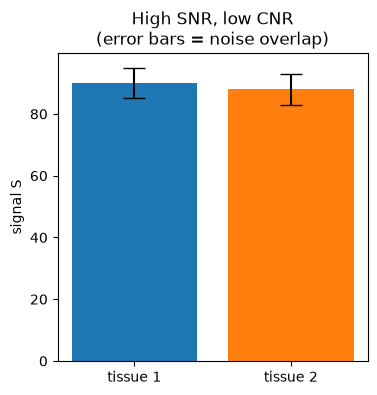

In [3]:
# Both tissues are bright (high SNR) but almost the same intensity (low CNR)
S1_demo, S2_demo = 90.0, 88.0

snr1 = S1_demo / SIGMA
snr2 = S2_demo / SIGMA
cnr_demo = abs(S1_demo - S2_demo) / SIGMA

print(f"SNR tissue 1 = {snr1:.2f}")
print(f"SNR tissue 2 = {snr2:.2f}")
print(f"CNR (1 vs 2) = {cnr_demo:.2f}   <-- excellent SNR, poor CNR")

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(["tissue 1", "tissue 2"], [S1_demo, S2_demo], yerr=SIGMA, capsize=8,
       color=["tab:blue", "tab:orange"])
ax.set_ylabel("signal S")
ax.set_title("High SNR, low CNR\n(error bars = noise overlap)")
plt.show()

## Optimizing CNR for an exponentially decaying signal

Model each tissue's signal as
$$S(k,t) = S_0\, e^{-k t},$$
where $k$ is a tissue property (decay rate) and $t$ is the experimental parameter we control
(measurement time). Different tissues have different $k$, so the contrast between them changes with
$t$.

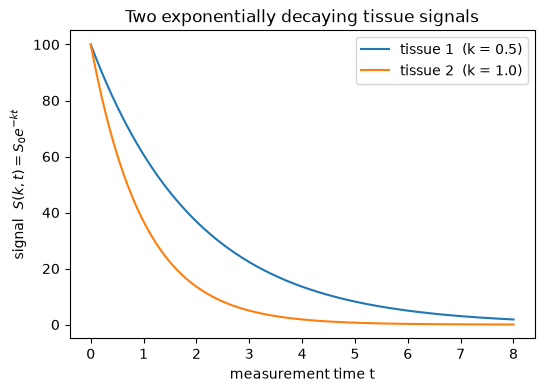

In [4]:
def S(k, t, S0=S0):
    """Exponentially decaying signal S(k, t) = S0 * exp(-k t)."""
    return S0 * np.exp(-k * t)


S1 = S(k1, t)
S2 = S(k2, t)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t, S1, label=f"tissue 1  (k = {k1})")
ax.plot(t, S2, label=f"tissue 2  (k = {k2})")
ax.set_xlabel("measurement time t")
ax.set_ylabel(r"signal  $S(k,t)=S_0 e^{-kt}$")
ax.set_title("Two exponentially decaying tissue signals")
ax.legend()
plt.show()

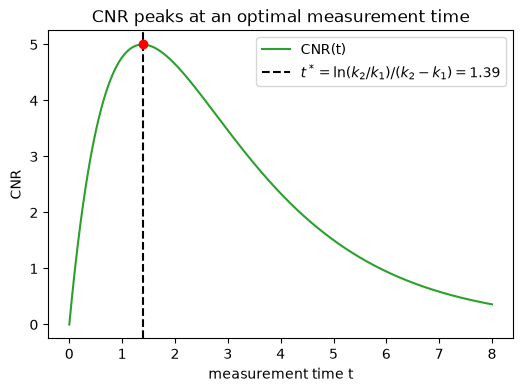

analytic  t* = 1.386   CNR_max = 5.000
numeric argmax t = 1.382 (matches t*)


In [5]:
# Contrast and CNR as a function of measurement time
contrast = np.abs(S1 - S2)
cnr_t = contrast / SIGMA

# Exact optimum for two DISTINCT decay rates: d/dt (S1 - S2) = 0
t_star = np.log(k2 / k1) / (k2 - k1)
cnr_max = abs(S(k1, t_star) - S(k2, t_star)) / SIGMA

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t, cnr_t, color="tab:green", label="CNR(t)")
ax.axvline(t_star, ls="--", color="k",
           label=fr"$t^* = \ln(k_2/k_1)/(k_2-k_1) = {t_star:.2f}$")
ax.plot(t_star, cnr_max, "ro")
ax.set_xlabel("measurement time t")
ax.set_ylabel("CNR")
ax.set_title("CNR peaks at an optimal measurement time")
ax.legend()
plt.show()

i = int(np.argmax(cnr_t))
print(f"analytic  t* = {t_star:.3f}   CNR_max = {cnr_max:.3f}")
print(f"numeric argmax t = {t[i]:.3f} (matches t*)")

## Error propagation: sensitivity to $k$ peaks at $t_0 = 1/k$

To discriminate tissues that differ in $k$, we want the signal to be as **sensitive to $k$** as
possible. The sensitivity is
$$\frac{\partial S}{\partial k} = -S_0\, t\, e^{-k t}.$$

Maximizing its magnitude over $t$ (set the $t$-derivative to zero):
$$\frac{\partial}{\partial t}\!\left(-S_0 t e^{-kt}\right) = -S_0 e^{-kt}\,(1 - k t) = 0
\;\Rightarrow\; \boxed{t_0 = 1/k}.$$

So **the optimal measurement time equals one time-constant, $1/k$.**

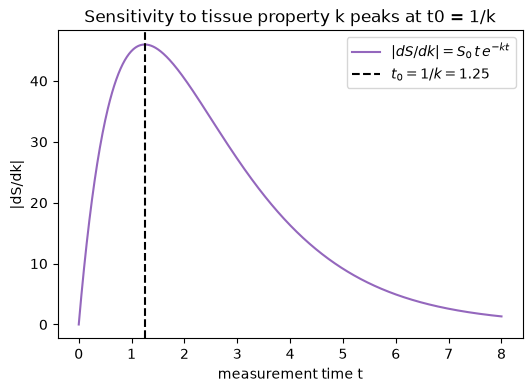

analytic t0 = 1/k       = 1.250
numeric argmax |dS/dk| at t = 1.252


In [6]:
k = 0.8                             # a single tissue's decay rate
dSdk = -S0 * t * np.exp(-k * t)     # analytic sensitivity  dS/dk
t0 = 1.0 / k                        # analytic optimum

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t, np.abs(dSdk), color="tab:purple", label=r"$|dS/dk| = S_0\, t\, e^{-kt}$")
ax.axvline(t0, ls="--", color="k", label=fr"$t_0 = 1/k = {t0:.2f}$")
ax.set_xlabel("measurement time t")
ax.set_ylabel("|dS/dk|")
ax.set_title("Sensitivity to tissue property k peaks at t0 = 1/k")
ax.legend()
plt.show()

i = int(np.argmax(np.abs(dSdk)))
print(f"analytic t0 = 1/k       = {t0:.3f}")
print(f"numeric argmax |dS/dk| at t = {t[i]:.3f}")

## Connecting the two views
The exact two-tissue optimum $t^* = \dfrac{\ln(k_2/k_1)}{k_2 - k_1}$ converges to the
sensitivity optimum $t_0 = 1/k$ as the two decay rates approach a common value $k$.

In [7]:
kbar = 0.8
print(f"target 1/kbar = {1/kbar:.4f}\n")
print(f"{'k1':>8}{'k2':>8}{'t*':>10}")
for eps in (0.5, 0.2, 0.1, 0.05, 0.01):
    ka, kb = kbar - eps / 2, kbar + eps / 2
    t_star_eps = np.log(kb / ka) / (kb - ka)
    print(f"{ka:>8.3f}{kb:>8.3f}{t_star_eps:>10.4f}")

target 1/kbar = 1.2500

      k1      k2        t*
   0.550   1.050    1.2933
   0.700   0.900    1.2566
   0.750   0.850    1.2516
   0.775   0.825    1.2504
   0.795   0.805    1.2500


## Takeaways
- **SNR** = $S/\sigma$ (precision of one signal); **CNR** = $(S_1-S_2)/\sigma$ (ability to separate two).
- High SNR does **not** guarantee high CNR: two bright but similar tissues have poor contrast.
- For an exponentially decaying signal, contrast (and sensitivity to the tissue property $k$) is
  **maximized at $t_0 = 1/k$** — measure at roughly one time-constant to optimize CNR.